In [1]:
# Data collection command:
# `python comet_download.py --project=core-transient-problem-variations-best --n_threads=8`

In [3]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.research_utils.analysis.analysis_utils import *
from phd.research_utils.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [4]:
save_path = 'figures/'
config_data_path = 'data/core-transient-problem-variations-best_params.csv'
run_data_path = 'data/core-transient-problem-variations-best_metrics.csv'

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)
# del config_dfs[np.nan], run_dfs[np.nan]

{k: len(v) for k, v in config_dfs.items()}

{'autostep': 60, 'sgd': 60, 'sgd_split_step_size': 60}

In [5]:
# print("_____Best Hyperparameter Configurations_____")
# sweep_ablation_vars = {
#     'autostep': ['optimizer|meta_learning_rate'],
#     'sgd': ['optimizer|learning_rate'],
#     'sgd_split_step_size': ['optimizer|learning_rate', 'representation_optimizer|learning_rate'],
# }
# sweep_split_vars = {
#     'autostep': ['model|use_perfect_features'],
#     'sgd': ['model|use_perfect_features'],
#     'sgd_split_step_size': ['model|use_perfect_features'],
# }


# best_config_dfs, best_run_dfs, best_var_vals = get_best_ablation_values(
#     config_dfs, run_dfs, sweep_ablation_vars, sweep_split_vars)

## Split DFs & Compute Normalized Loss

In [6]:
combined_run_df = pd.concat(run_dfs.values())
combined_config_df = pd.concat(config_dfs.values())

combined_config_df.loc[:, 'Algorithm'] = combined_config_df['sweep_name'].apply(
    lambda x: {
        'sgd': 'SGD',
        'sgd_split_step_size': 'Split SGD',
        'autostep': 'Autostep',
    }[x]
)

combined_config_df.loc[:, 'Features Given'] = combined_config_df['model|use_perfect_features']

learned_run_df, learned_config_df = select_experiment_runs(
    run_df = combined_run_df,
    config_df = combined_config_df,
    chosen_values = {
        'model|use_perfect_features': False,
    },
)

given_run_df, given_config_df = select_experiment_runs(
    run_df = combined_run_df,
    config_df = combined_config_df,
    chosen_values = {
        'model|use_perfect_features': True,
    },
)


In [7]:
# First, merge to get the required columns into a single DataFrame
all_combined_df = combined_run_df.merge(
    combined_config_df[['run_id', 'model|use_perfect_features', 'seed', 'Algorithm']],
    on='run_id',
)

# Keep only the columns we care about
cols_of_interest = [
    'run_id',
    'model|use_perfect_features',
    'seed',
    'step',
    'loss',
    'Algorithm',
]
all_combined_df = all_combined_df[cols_of_interest]

# Pivot to get False and True losses side-by-side
pivot_df = all_combined_df.pivot_table(
    index = ['seed', 'step', 'Algorithm'],
    columns = 'model|use_perfect_features',
    values = 'loss',
    aggfunc = 'first',
)

# Compute the ratio (no_pf_loss / pf_loss)
ratio = pivot_df[False] / pivot_df[True]

# Create a mapping for normalized loss
normalized_map = ratio.to_frame(name='normalized_loss_false').reset_index()
normalized_map['normalized_loss_true'] = 1.0

# Map back to original dataframe
all_combined_df = all_combined_df.merge(
    normalized_map[['seed', 'step', 'Algorithm', 'normalized_loss_false']],
    on = ['seed', 'step', 'Algorithm'],
    how = 'left',
)
all_combined_df['normalized_loss'] = np.where(
    all_combined_df['model|use_perfect_features'],
    1.0,
    all_combined_df['normalized_loss_false']
)
all_combined_df = all_combined_df.drop(columns=['normalized_loss_false'])

combined_run_df = combined_run_df.merge(
    all_combined_df[['run_id', 'step', 'normalized_loss']],
    on = ['run_id', 'step'],
    how = 'left',
)

## Learning Curves

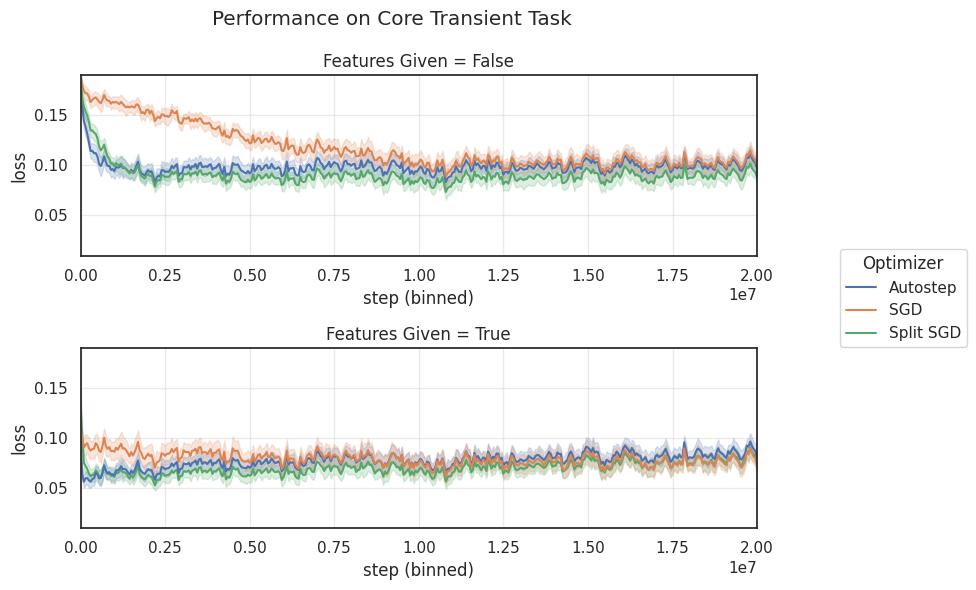

In [8]:
plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 400,
    figsize = (8, 6),
    max_cols = 1,
    hue_col = 'Algorithm',
    subplot_col = 'Features Given',
    legend_title = 'Optimizer',
    show_ci = True,
)
plt.suptitle('Performance on Core Transient Task')
plt.tight_layout()
plt.show()

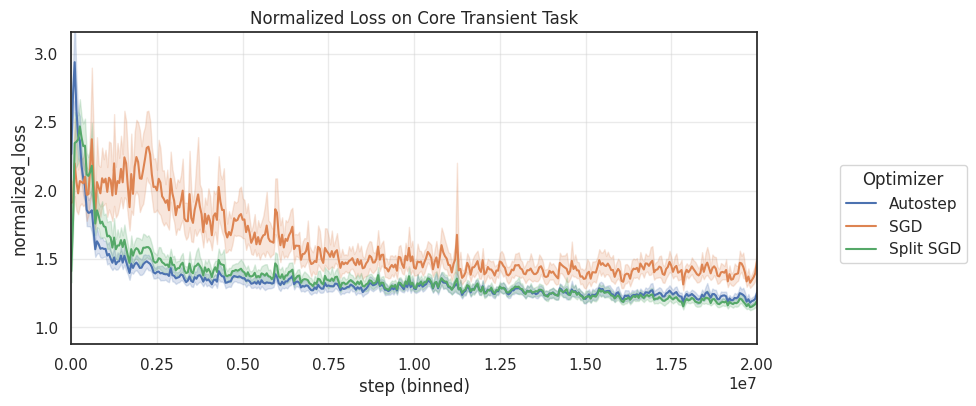

In [13]:
plot_run_df, plot_config_df = select_experiment_runs(
    run_df = combined_run_df,
    config_df = combined_config_df,
    chosen_values = {
        'Features Given': False,
    },
)

plot_learning_curves(
    run_df = plot_run_df,
    config_df = plot_config_df,
    n_bins = 400,
    figsize = (8, 4),
    # max_cols = 1,
    y_col = 'normalized_loss',
    hue_col = 'Algorithm',
    # subplot_col = 'Features Given',
    legend_title = 'Optimizer',
    show_ci = True,
)
plt.title('Normalized Loss on Core Transient Task')
# plt.tight_layout()
plt.show()

## Update Stats

In [9]:
# Reshape learned_run_df so 'mean_l1' columns are stacked, and have a 'layer_idx' column
mean_l1_cols = [f'updates/layer_{i}/mean_l1' for i in range(4)]
# melt to long format
mean_l1_long = learned_run_df.melt(
    id_vars=[col for col in learned_run_df.columns if col not in mean_l1_cols],
    value_vars = mean_l1_cols,
    var_name = 'layer_mean_l1',
    value_name = 'mean_l1'
)
# Extract layer index as integer
mean_l1_long['layer_idx'] = mean_l1_long['layer_mean_l1'].str.extract(r'layer_(\d+)/mean_l1').astype(int)
# Now mean_l1_long has one 'mean_l1' column and a 'layer_idx' column, with 4x the rows.

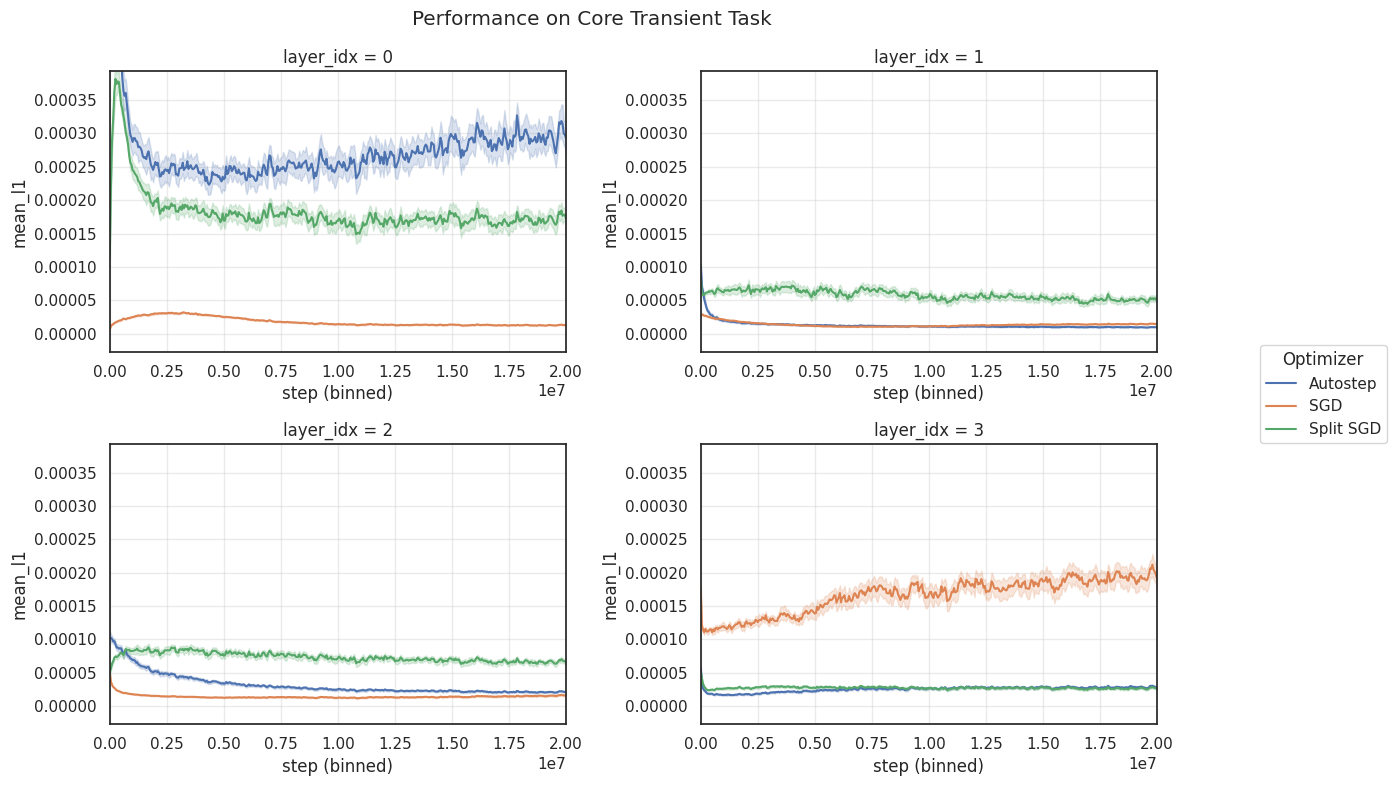

In [10]:
plot_learning_curves(
    run_df = mean_l1_long, # learned_run_df,
    config_df = learned_config_df,
    n_bins = 400,
    figsize = (12, 8),
    hue_col = 'Algorithm',
    legend_title = 'Optimizer',
    y_col = 'mean_l1',
    same_y_axis = True,
    max_cols = 2,
    subplot_col = 'layer_idx',
    show_ci = True,
)
plt.suptitle('Performance on Core Transient Task')
plt.tight_layout()
plt.show()

## Step-Size Stats

In [11]:
# Filter to only autostep learned features
autostep_learned_run_df, autostep_learned_config_df = select_experiment_runs(
    run_df = learned_run_df,
    config_df = learned_config_df,
    chosen_values = {
        'Algorithm': 'Autostep',
    },
)

# Reshape autostep_learned_run_df so 'beta_mean' columns are stacked, and have a 'layer_idx' column
beta_mean_cols = [f'optimizer/layer_{i}/beta_mean' for i in range(4)]
# melt to long format
beta_mean_long = autostep_learned_run_df.melt(
    id_vars = [col for col in autostep_learned_run_df.columns if col not in beta_mean_cols],
    value_vars = beta_mean_cols,
    var_name = 'layer_beta_mean',
    value_name = 'beta_mean'
)
# Extract layer index as integer
beta_mean_long['layer_idx'] = beta_mean_long['layer_beta_mean'].str.extract(r'layer_(\d+)/beta_mean').astype(int)
# Now beta_mean_long has one 'beta_mean' column and a 'layer_idx' column, with 4x the rows.

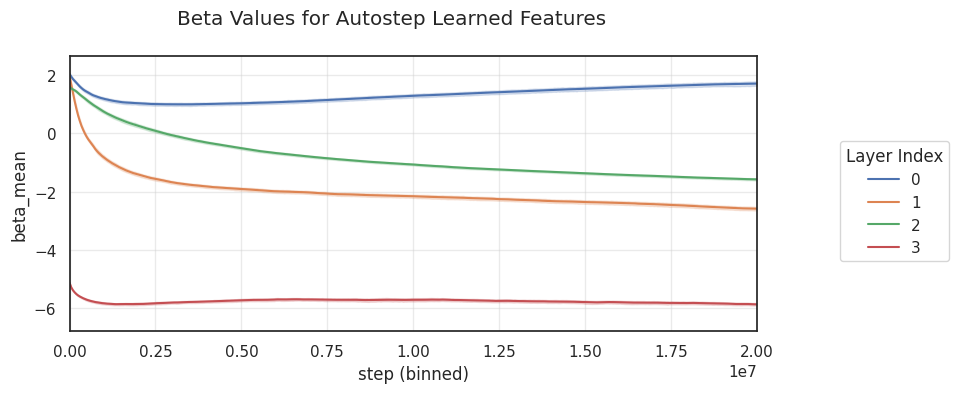

In [12]:
plot_learning_curves(
    run_df = beta_mean_long,
    config_df = autostep_learned_config_df,
    n_bins = 400,
    figsize = (8, 4),
    hue_col = 'layer_idx',
    # subplot_col = 'layer_idx',
    legend_title = 'Layer Index',
    y_col = 'beta_mean',
    show_ci = True,
)
plt.suptitle('Beta Values for Autostep Learned Features')
plt.tight_layout()
plt.show()